In [6]:
import pandas as pd
import plotly as plt
import os
from IPython.display import display
import ipywidgets as widgets
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

In [2]:
import requests

def download(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, "wb") as f:
            f.write(response.content)
        print(f"Downloaded {filename} successfully.")
    else:
        print(f"Failed to fetch {url}. Status: {response.status_code}")


download(URL, "dataset.csv")


Downloaded dataset.csv successfully.


In [18]:
df = pd.read_csv(URL)
column_with_mission_values = df.columns[df.isnull().any()]
missing_rows = df[df.isnull().any(axis=1)]
display(column_with_mission_values)
display(missing_rows)

Index(['Screen_Size_cm', 'Weight_kg'], dtype='object')

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
29,29,HP,3,IPS Panel,3,1,5,35.560,2.5,6,256,NaN,837
38,38,HP,3,IPS Panel,2,1,5,33.020,2.5,4,256,NaN,888
49,49,Dell,4,Full HD,2,1,5,33.782,1.6,8,256,NaN,1777
61,61,Dell,3,Full HD,1,2,7,39.624,2.7,16,256,NaN,1142
68,68,Dell,3,Full HD,1,2,7,39.624,1.8,8,256,NaN,934
120,120,Dell,4,Full HD,2,1,5,NaN,1.6,8,256,1.42,2340
151,151,Dell,5,Full HD,3,1,7,NaN,2.8,8,256,2.06,2240
187,187,Samsung,4,Full HD,2,1,7,NaN,2.7,8,256,1.31,2031
230,230,Dell,4,Full HD,2,1,5,NaN,2.5,8,256,1.36,1870


In [25]:
description = df.describe(include='all')
print(description)

        Unnamed: 0 Manufacturer    Category         GPU          OS  \
count   238.000000          238  238.000000  238.000000  238.000000   
unique         NaN           11         NaN         NaN         NaN   
top            NaN         Dell         NaN         NaN         NaN   
freq           NaN           71         NaN         NaN         NaN   
mean    118.500000          NaN    3.205882    2.151261    1.058824   
std      68.848868          NaN    0.776533    0.638282    0.235790   
min       0.000000          NaN    1.000000    1.000000    1.000000   
25%      59.250000          NaN    3.000000    2.000000    1.000000   
50%     118.500000          NaN    3.000000    2.000000    1.000000   
75%     177.750000          NaN    4.000000    3.000000    1.000000   
max     237.000000          NaN    5.000000    3.000000    2.000000   

          CPU_core  Screen_Size_cm  CPU_frequency      RAM_GB  Storage_GB_SSD  \
count   238.000000      234.000000     238.000000  238.000000     

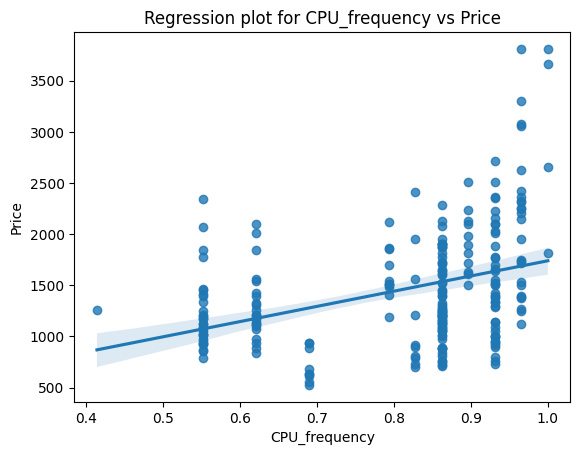

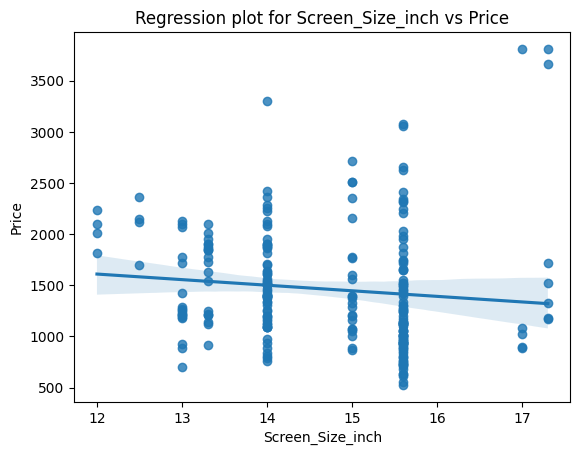

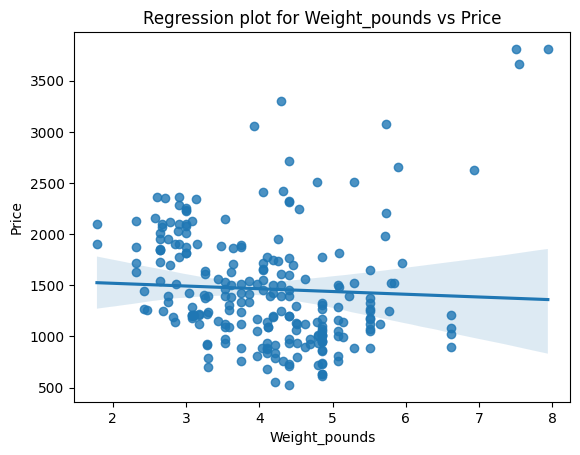

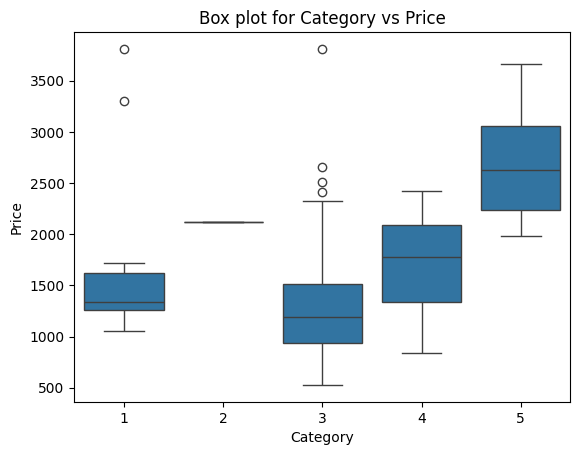

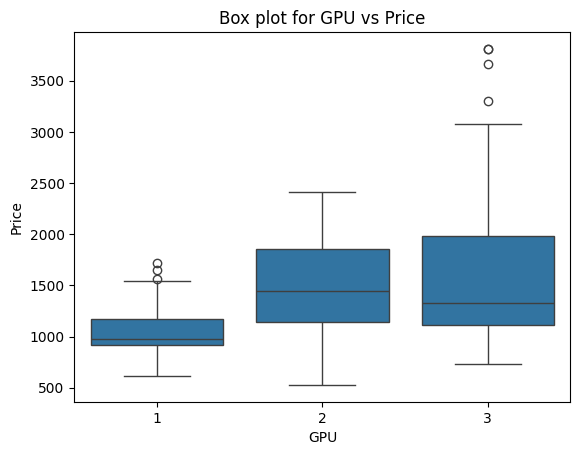

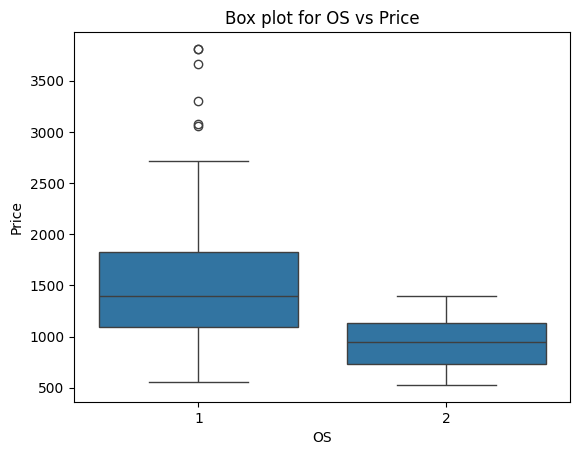

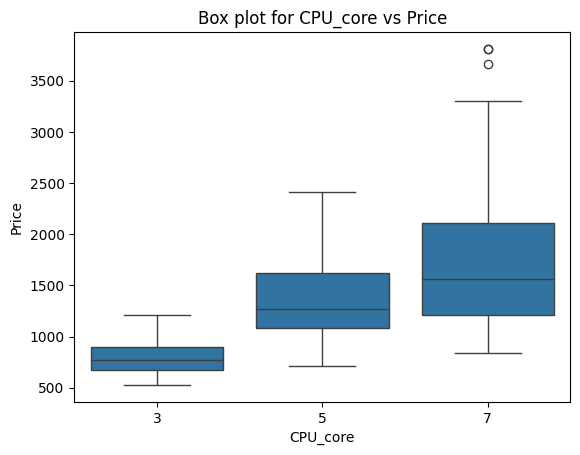

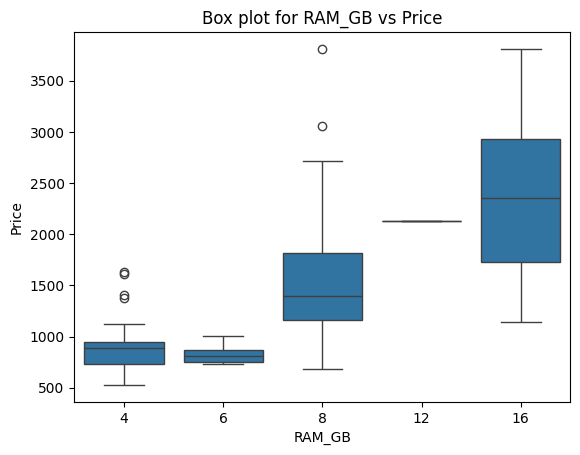

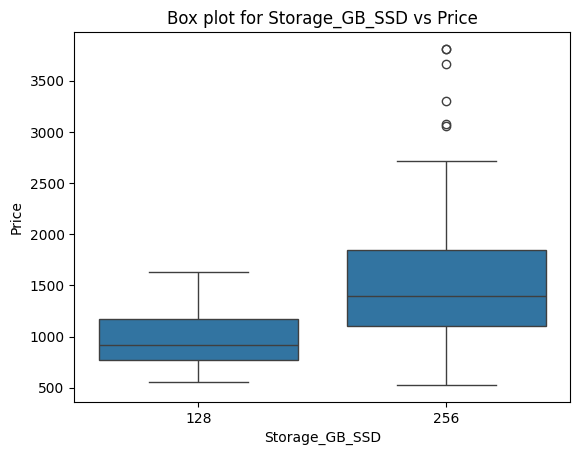

In [4]:
# 1. Create regression plots
data = pd.read_csv('dataset.csv')

regression_attributes = ['CPU_frequency', 'Screen_Size_inch', 'Weight_pounds']
for attribute in regression_attributes:
    sns.regplot(x=attribute, y='Price', data=data)
    plt.title(f'Regression plot for {attribute} vs Price')
    plt.xlabel(attribute)
    plt.ylabel('Price')
    plt.show()

# 2. Create box plots
boxplot_attributes = ['Category', 'GPU', 'OS', 'CPU_core', 'RAM_GB', 'Storage_GB_SSD']
for attribute in boxplot_attributes:
    sns.boxplot(x=attribute, y='Price', data=data)
    plt.title(f'Box plot for {attribute} vs Price')
    plt.xlabel(attribute)
    plt.ylabel('Price')
    plt.show()

In [7]:
# 1. Evaluate the correlation value, pearson coefficient and p-values for all numerical attributes against the target attribute "Price".
# 2. Don't include the values evaluated for target variable against itself.
# 3. Print these values as a part of a single dataframe against each individual attribute.

# Assuming your dataframe has a target attribute 'Price'
df = pd.read_csv('dataset.csv')

# Select numerical attributes
numerical_attributes = df.select_dtypes(include=np.number)

# Calculate correlation values for all numerical attributes against 'Price'
correlation_values = numerical_attributes.corr()['Price'].drop('Price')

# Calculate Pearson coefficient and p-values for all numerical attributes against 'Price'
pearson_coefficients = []
p_values = []

for column in numerical_attributes.columns:
    if column != 'Price':
        pearson_coefficient, p_value = pearsonr(numerical_attributes[column], df['Price'])
        pearson_coefficients.append(pearson_coefficient)
        p_values.append(p_value)

# Create a new dataframe to store the results
results_df = pd.DataFrame({'Attribute': correlation_values.index, 'Correlation Value': correlation_values, 'Pearson Coefficient': pearson_coefficients, 'P-value': p_values})

# Print the results
print(results_df)

                         Attribute  Correlation Value  Pearson Coefficient  \
Unnamed: 0.1          Unnamed: 0.1           0.321933             0.321933   
Unnamed: 0              Unnamed: 0           0.321933             0.321933   
Category                  Category           0.286243             0.286243   
GPU                            GPU           0.288298             0.288298   
OS                              OS          -0.221730            -0.221730   
CPU_core                  CPU_core           0.459398             0.459398   
Screen_Size_inch  Screen_Size_inch          -0.110644            -0.110644   
CPU_frequency        CPU_frequency           0.366666             0.366666   
RAM_GB                      RAM_GB           0.549297             0.549297   
Storage_GB_SSD      Storage_GB_SSD           0.243421             0.243421   
Weight_pounds        Weight_pounds          -0.050312            -0.050312   
Screen-Full_HD      Screen-Full_HD          -0.021075           

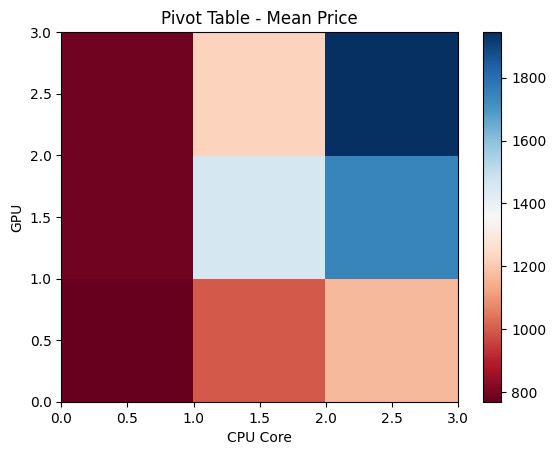

In [8]:
# 1. Group the attributes "GPU", "CPU_core" and "Price", as available in a dataframe df
# 2. Create a pivot table for this group, assuming the target variable to be 'Price' and aggregation function as mean
# 3. Plot a pcolor plot for this pivot table.


# Import the data set as a pandas DataFrame
df = pd.read_csv('dataset.csv')

# Group the attributes
grouped_data = df.groupby(['GPU', 'CPU_core'])['Price'].mean()

# Create a pivot table
pivot_table = pd.pivot_table(df, values='Price', index='GPU', columns='CPU_core', aggfunc='mean')

# Plot a pcolor plot
plt.pcolor(pivot_table, cmap='RdBu')
plt.colorbar()
plt.title('Pivot Table - Mean Price')
plt.xlabel('CPU Core')
plt.ylabel('GPU')
plt.show()
